## AI4Climate ML tutorial - template
* Author: <INSERT AUTHOR>
* Affiliation: UK Met Office
* History: 1.0
* Last update: 2026-02-10
* © British Crown Copyright 2017-2065, Met Office. Please see LICENSE.md for license details.

## Overview of the broad topic covered

In this notebook, we will use the previously prepared tabular dataset to predict climate zones. We will train on different eras to see how well the results generalise with climate change. 

### Prerequisites 
what background information is needed to go through the notebook
- Same as previouis notebooks
- Have completed data exploration notebook

### Learning outcomes from completing the notebook

- Understand the key components of a machine learning training pipeline and how they fit together
- Understand key terminology in describing the machine learning pipeline
- Initial understanding of how to choose appropriate components for each stage in the pipeline.

## Tutorial - Key Elements of a Machine Learning Pipeline

Using a series of data science and machine learning and algorithms to go from input data to a series of predictions is usually referred to as a pipeline. In this noteboook we will be exploring the key components of such a pipeline in constructing and training a machine learning algorithm with some input data.

In this notebook we will look at 2 pipeline, one for a supervised classification problem, and the other for an unsupervised clustering problem.

The steps we willl go through are as follows:
1. Data Loading & Cleaning - Start by loading the data, and filtering out any data considered to be unsuitable training and evaluation of machine learning algorithms. Selection of appropriate data is an important way in which domain expertise in vital in getting good results.
2. Feature Engineering - The first step is to prepare the data for presenting to the algorithm. Different ways of presenting the data will emphasise different features, and choosing the right features is important for getting good results. Knowledge of what features represent based on domain knowledge is again very important.
3. Train/test Split - Before we train the algorithm, we need to split into train and test sets. This is to ensure out algorithm doesn't overfit, learning irrelevant details that are not representative of the whole space of possible data, but rather that in generalises well.
4. Data Preparation - The machine learning algorithm only sees numbers as numbers, with no inherent understanding of meaning or context. We need to ensure different features are scaled to be comparable, otherwise big numbers will be treated as more important by the algorithm, irrespective of what those numbers mean. Value are typically scaled to a range of [0,1] or, assuming a gaussian distribution, to have mean=0 and std_dev=1.
5. Algorithm Setup - Here we select the particular algorithm e,.g. neural network, k-means clustering, and specify the hyperparameters. It is important to distinguish between parameters and hyperparameters.
    - Parameters are the values that calculated by the training process.
    - Hyperparameters are values specified in algorithm setup, which are not altered by training. These need to be fine-tuned using an additional outer training loop called hyperparameter tuning.
6. Algorithm Training - Execute the algorithm to calculate the best parameters for the chosen ML algorithm to fit the supplied training data
7. Inference - Once we have an algorithm, we use it to produce predictions, for both the train and test sets.
8. Evaluation - We then compare the predictions of the trained algorithms to expected results. For supervised learning, this will be supplied target values. For unsupervised learning, we will explore the results and their usefulness much like in exploratory data analysis.
9. Interpretability & Explainability - Machine learning models are often treated as black-boxes, that is we can't know or understand how or why the algoriothm produces a particular output. Explainability and interpretability aim to change this, giving insight on the internals of the algorithms (explainability) and guidance on interpeting a particular result (interpretability).
10. Model Storage - Model training can be an expensive process that we don't want to perform too often, and. once we have a model that performs well we save its state so it can be reloaded and used subsequently for inference on later problems.


### Key Terms

- *supervised learning* - training an algorithm to map from input to target data or labels.
- *unsupervised learning* - training an algorithm to find structure in data that has no labels.
- *regression* - An algorithm that predicts a continuous values.
- *classification* - An algorithm that predicts from a set of discrete values
- *metric* - A measure of the performance of the ML algorithm.
- *parameter* - A value in the algorithm that is determined by the training process e.g. neural network weights or decision tree thresholds.
- *hyperparameter* - A value in the algorithm that is not determined by training and must be specified or tuned. e.g. number of hidden layers or max number of decision tree levels.
- *feature engineering* - the process of creating input variables for the ML aglorithm that will give desirable results.
- *training set* - The subset of your data that you use for training your algorithm.
- *validation set* - The subset of your data that you use for testing your trained algorithm and which informs subsequent development to improve results.
- *test set*- The subset of your data that you set aside and do not use while developing the algorithm. Once the development process is finished, you check the final result with
this subset of the data to check it truly generalises to unseen data.
*inference* - Calculating predictions from input data used a trained algorithm.

More information on jargon
- [Google Machine Learning Glossary](https://developers.google.com/machine-learning/glossary)
- [ML Cheatsheet](https://ml-cheatsheet.readthedocs.io/en/latest/glossary.html)


## Setup
First we start by loading the data we have prepared previously, and other set up elements

### Imports

In [2]:
import pathlib
import os
import datetime
import json

In [3]:
import pandas

In [52]:
import matplotlib
import matplotlib.pyplot

In [5]:
import sklearn
import sklearn.preprocessing
import sklearn.tree
import torch

In [6]:
import pickle

## Step 1 - Data Loading and Cleaning

#### Dataset parameters
Start by defininng the parameters to use for loading the dataset. These have been collected into a config file for use across the notebooks in this tutorial material.

In [7]:
with open ('config.json','r') as tutorial_config:
    tutorial_config = json.load(tutorial_config)
tutorial_config

{'platform': 'mo_linux',
 'default_dirs': {'mo_linux': '/data/users/dscop/ml_tutorial/',
  'jasmin': '/gws/nopw/j04/mohc_shared/dscop/'},
 'random_seed': 12345,
 'climate_subgroups': {'non-land': 'None',
  'Af': 'Tropical, rainforest',
  'Am': 'Tropical, monsoon',
  'Aw': 'Tropical, savannah',
  'BWh': 'Arid, desert, hot',
  'BWk': 'Arid, desert, cold',
  'BSh': 'Arid, steppe, hot',
  'BSk': 'Arid, steppe, cold',
  'Csa': 'Temperate, dry summer, hot summer',
  'Csb': 'Temperate, dry summer, warm summer',
  'Csc': 'Temperate, dry summer, cold summer',
  'Cwa': 'Temperate, dry winter, hot summer',
  'Cwb': 'Temperate, dry winter, warm summer',
  'Cwc': 'Temperate, dry winter, cold summer',
  'Cfa': 'Temperate, no dry season, hot summer',
  'Cfb': 'Temperate, no dry season, warm summer',
  'Cfc': 'Temperate, no dry season, cold summer',
  'Dsa': 'Cold, dry summer, hot summer',
  'Dsb': 'Cold, dry summer, warm summer',
  'Dsc': 'Cold, dry summer, cold summer',
  'Dsd': 'Cold, dry summer, v

In [8]:
def get_platform_dir(select_platform, config):
    try:
        root_path = pathlib.Path(config['default_dirs'][select_platform]) / 'climate_zones'
    except KeyError:
        root_path = pathlib.Path(os.environ['HOME']) / 'climate_zones'
    return root_path

In [9]:
current_platform = tutorial_config['platform']

In [10]:
root_data_dir = get_platform_dir(current_platform, tutorial_config)

print(root_data_dir.is_dir())
root_data_dir

True


PosixPath('/data/users/dscop/ml_tutorial/climate_zones')

In [11]:
ml_ready_dir = root_data_dir / 'ml_ready'
print(ml_ready_dir.is_dir())
ml_ready_dir

True


PosixPath('/data/users/dscop/ml_tutorial/climate_zones/ml_ready')

In [12]:
resolutions_dict = {float(k1): v1 for k1,v1 in tutorial_config['resolutions_names'].items()}

dataset_prefix_dict = tutorial_config['dataset_prefix']

format_str = 'nc'
historic_scenario_str = 'historic'

future_scenario_list = tutorial_config['future_scenarios']
historic_scenario_list = tutorial_config['historic_scenarios']

time_periods = { 
    (1901,1930): historic_scenario_list, 
    (1931,1960): historic_scenario_list,
    (1961,1990): historic_scenario_list,
    (1991,2020): historic_scenario_list,
    (2041,2070): future_scenario_list,
    (2071,2099): future_scenario_list,
}


In [13]:
fname_template = tutorial_config['fname_template']
time_dir_template = tutorial_config['time_dir_template']
ml_ready_fname_template = tutorial_config['csv_out_template']

### Load data for training

In [14]:
current_res = 1.0

In [15]:
mlready_data_path = ml_ready_dir / ml_ready_fname_template.format(resolution=resolutions_dict[current_res])
print(mlready_data_path.is_file())
mlready_data_path

True


PosixPath('/data/users/dscop/ml_tutorial/climate_zones/ml_ready/climate_zones_1p0.csv')

In [16]:
zones_df = pandas.read_csv(mlready_data_path)

In [17]:
# reducing the total data point to decrease memeory requirements
# zones_df = zones_df[() & zones_df['scenario'] == 'historic']

In [18]:
zones_df

,lat,lon,precipitation_1.0_mean,precipitation_2.0_mean,precipitation_3.0_mean,precipitation_4.0_mean,precipitation_5.0_mean,precipitation_6.0_mean,precipitation_7.0_mean,precipitation_8.0_mean,...,air_temperature_10.0_std,air_temperature_11.0_std,air_temperature_12.0_std,kg_class,kg_confidence,period_start,period_end,scenario,climate_group,climate_subgroup
0,83.5,-38.5,12.1250,8.2500,8.9375,21.8750,15.5000,29.8750,35.8750,46.1250,...,2.5625,3.3125,3.6250,29.0,83.0,1901,1930,historic,E,E
1,83.5,-37.5,10.8750,8.1250,8.6250,19.6250,13.8125,26.8750,32.0625,42.0000,...,3.0000,3.8125,4.1250,30.0,86.0,1901,1930,historic,E,E
2,83.5,-36.5,9.9375,8.4375,8.8125,18.1250,12.3750,23.6875,28.5000,37.8125,...,2.5000,3.1875,3.4375,30.0,84.0,1901,1930,historic,E,E
3,83.5,-35.5,10.0000,8.8750,9.0625,17.6250,12.0000,22.4375,26.9375,35.9375,...,2.3750,3.1250,3.4375,30.0,86.0,1901,1930,historic,E,E
4,83.5,-34.5,10.1250,9.1875,9.4375,16.7500,11.3750,20.6250,24.9375,33.3750,...,1.9375,2.5000,2.8750,30.0,76.0,1901,1930,historic,E,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406489,-89.5,175.5,4.0000,4.5625,6.6250,7.0000,7.1875,5.7500,5.6250,8.3125,...,1.1250,1.1250,1.4375,30.0,100.0,2071,2099,ssp585,E,E
406490,-89.5,176.5,4.0000,4.5625,6.6875,7.0625,7.2500,5.8125,5.6250,8.4375,...,1.1250,1.1250,1.4375,30.0,100.0,2071,2099,ssp585,E,E
406491,-89.5,177.5,4.0625,4.6250,6.6875,7.1250,7.3125,5.8125,5.6875,8.7500,...,1.1250,1.1250,1.4375,30.0,100.0,2071,2099,ssp585,E,E
406492,-89.5,178.5,4.0625,4.6250,6.6875,7.1250,7.3125,5.8125,5.6875,9.0000,...,1.1250,1.1875,1.4375,30.0,100.0,2071,2099,ssp585,E,E


In [19]:
zones_df.columns

Index(['lat', 'lon', 'precipitation_1.0_mean', 'precipitation_2.0_mean',
       'precipitation_3.0_mean', 'precipitation_4.0_mean',
       'precipitation_5.0_mean', 'precipitation_6.0_mean',
       'precipitation_7.0_mean', 'precipitation_8.0_mean',
       'precipitation_9.0_mean', 'precipitation_10.0_mean',
       'precipitation_11.0_mean', 'precipitation_12.0_mean',
       'air_temperature_1.0_mean', 'air_temperature_2.0_mean',
       'air_temperature_3.0_mean', 'air_temperature_4.0_mean',
       'air_temperature_5.0_mean', 'air_temperature_6.0_mean',
       'air_temperature_7.0_mean', 'air_temperature_8.0_mean',
       'air_temperature_9.0_mean', 'air_temperature_10.0_mean',
       'air_temperature_11.0_mean', 'air_temperature_12.0_mean',
       'precipitation_1.0_std', 'precipitation_2.0_std',
       'precipitation_3.0_std', 'precipitation_4.0_std',
       'precipitation_5.0_std', 'precipitation_6.0_std',
       'precipitation_7.0_std', 'precipitation_8.0_std',
       'precipitatio

## 2. Feature Engineering

Feature engineering is about preparing the dataset for use training learning algorithm. There are a variety of different tasks that form part of this
* Selecting a subset of data e.g. by time, spatial extent, certain variables/fields
* Transforming the data in some way e.g. changing resolution, transforming from gridded to tabular.
* Calcualting dervived variables from combinations of variables e.g. wind speed from u and v wind.
* Calcuating summary variables e.g. daily maxima or monthly means from hourly data.

### ML Ready data

This data preparation step can be very time consuming for a variety of reasons:
* Although you may know of a dataset, yo many not immediately know how to find or access it
* you often need to load and explore the data to decide what to use, especially if there is inadequate documentation
* the data may not easily work with tools that you are already familair
* you need to understand the data contents to understand how to use it in a sicnetifically valid way with machine learning tools. It is expcially important to under the limitations of the data and its usage.

The difficulty in using data with data driven techniques such as machine learning can limit the value of the data. As a result increasingly dataset creators, maintainers and curators are looking to ensure they package the data in way that is *ML-ready* or *AI-ready*. More information on what this means can be found in the repository, which includes documentation and exaples of how to assess whether your dataset in ML ready.
* [AI Data Readiness Github Repository](https://github.com/MetOffice/ai_data_readiness)

#### Climate Zones Feature Engineering

Most of the feature engineering for this dataset is done in the Data Prep notebook, so look at that notebook to see the code used. The the feature engineering process was as follows:
* We started with global gridded data fields, for a variety of historical and future periods spanning 200 years at different resolution, representing:
  * Monthly means of mean and standard deviation for air temperature and precipitation
  * Climate Zone Classificaton for each land point on earth
* We grouped our dataset by period and scenario
* We transformed from a gridded format to a tabular format. The reason for doing that is so we consider each point on the map as separate data point, rather than a whole global map. This means we have many more training examples.
* We excluded all the non-land points, as they have no climate classification
* We changed the climate zone feature from just being a number to have the proper zone description string e.g. `Af`, so that the data is more self describing.
* We calculated a second zone field, which contains only the major groupings of zones, such as `A` and `B`, rather than subgroups like `Af` or `Bsh`. This means there are only 5 classification classes which makes training the ML easier, and requires a smaller training dataset for good results.
* We did this processing for subset (time period, scenario) and added the start and end of the period and scenario name as features, so we could then concatenate all the data into a single tabular dataset.
* We then saved out the data in a relevant format.


We have the following predictors avaialable for training. We'll start by using only the climate means as predictors, and only aiming for the 5 classes, rather than the full 30. 

In [20]:
predictors_dict = {
    'precip_mean': [c1 for c1 in zones_df.columns if 'precipitation' in c1 and 'mean' in c1],
    'precip_std': [c1 for c1 in zones_df.columns if 'precipitation' in c1 and 'std' in c1],
    'temp_mean': [c1 for c1 in zones_df.columns if 'air_temperature' in c1 and 'mean' in c1],
    'temp_std': [c1 for c1 in zones_df.columns if 'air_temperature' in c1 and 'std' in c1],
}


In [21]:
predictors = predictors_dict['precip_mean'] + predictors_dict['temp_mean']
predictors

['precipitation_1.0_mean',
 'precipitation_2.0_mean',
 'precipitation_3.0_mean',
 'precipitation_4.0_mean',
 'precipitation_5.0_mean',
 'precipitation_6.0_mean',
 'precipitation_7.0_mean',
 'precipitation_8.0_mean',
 'precipitation_9.0_mean',
 'precipitation_10.0_mean',
 'precipitation_11.0_mean',
 'precipitation_12.0_mean',
 'air_temperature_1.0_mean',
 'air_temperature_2.0_mean',
 'air_temperature_3.0_mean',
 'air_temperature_4.0_mean',
 'air_temperature_5.0_mean',
 'air_temperature_6.0_mean',
 'air_temperature_7.0_mean',
 'air_temperature_8.0_mean',
 'air_temperature_9.0_mean',
 'air_temperature_10.0_mean',
 'air_temperature_11.0_mean',
 'air_temperature_12.0_mean']

We have two options for the target. We have the full 30 class climate subgroups of the Koppen-Geiger classification data from the original dataset. We also have the processed five class climate group target, which presents an easier target for our classification algorithm to predict.

In [22]:
target_var = 'climate_group' # 5 classes
# target_var = 'climate_subgroup # 30 classes


## 3. Train/test split

The next step is to [split the data into different subsets](https://www.geeksforgeeks.org/machine-learning/how-to-do-train-test-split-using-sklearn-in-python/) called *train*, *validation* and *test* sets. This to check how well what the algorithm learn generalises to unseen data, so it learns the true meaningful data relationship of interest, rather than suprious connections or noise present in the particular training examples. The different subsets are used as follows:
- *train* set This is used in the training loop for calculating the error in predictions with current parameters and then upating the weight towards a better prediction. For neural networks, this is done through one or other variant on the "gradient descent with back propogation" algorithm.
- *validation* or *dev* set - This is used for checking each model trained e.g. varying hyparameters like number of neurons or layer, or learning rate. The data is not seen during the triaing loop, so shows whether the model has learnt general relationships.
- *test* set - This data is put aside during model development until development is finished, and then the final model is tested using this data. The reason for this additional test is that during dev or validation process, the hyperparameters could have been selected that were particular to the data in validation set but are not representative of general performance. The final test on the test shows whether performance o the validation set represents genuine learning by the model.

 ### Considerations
 - consistency of distributions
- class imbalance
- correlation between samples

### Methods

There are various ways of selecting subsets
* Random - Specify which fraction of the dataset goes into each set and select at random
  * A typical fraction is 80%/10%10% for train/val/test.
  * One issue with this is points that are correlated may be in different sets, rsulting in *information leakage* which reduces the meaningfulness of evluation with validation and test sets. Correlation could be due to temporal or spatial proximty, or other reasons.
* Weighted - Rather than selecting at random from the data, one can divide the data by class or for particular attribute, and then randomly assign to trai, validation or test for each point. This ensure a balanced reperesention of data acrosss different sets. 
* Rebalanced - Similar to weighted, but instead of using all available data, the data is u=subsampled to provide equal memebers of each target class in the training dataset.
* Temporal - Select different time periods, for example by year.


In [23]:
random_seed = tutorial_config['random_seed']

In [24]:
test_frac = 0.1
val_frac = 0.1
val_frac_sub = (val_frac / (1.0-test_frac) )

In [25]:
test_df = zones_df.groupby(['period_start','scenario']).sample(frac=test_frac, random_state=random_seed)
remain_df = zones_df.drop(test_df.index)

In [26]:
val_df = remain_df.groupby(['period_start','scenario']).sample(frac=val_frac_sub, random_state=random_seed)
train_df = remain_df.drop(val_df.index)


In [27]:
# For running through notebook really quickly for debugging
# train_df = train_df.sample(n=int(1e4))

## 4. Data Preparation
Now we prepare the data for ingestion by the ML training process. This is a about the mechanics of ML algorithms, where values for different features need to be normalised so are they are considered equally important by the algorithm.

In [28]:
train_df[predictors].describe()

,precipitation_1.0_mean,precipitation_2.0_mean,precipitation_3.0_mean,precipitation_4.0_mean,precipitation_5.0_mean,precipitation_6.0_mean,precipitation_7.0_mean,precipitation_8.0_mean,precipitation_9.0_mean,precipitation_10.0_mean,...,air_temperature_3.0_mean,air_temperature_4.0_mean,air_temperature_5.0_mean,air_temperature_6.0_mean,air_temperature_7.0_mean,air_temperature_8.0_mean,air_temperature_9.0_mean,air_temperature_10.0_mean,air_temperature_11.0_mean,air_temperature_12.0_mean
count,325206.000000,325206.000000,325206.000000,325206.000000,325206.000000,325206.000000,325206.000000,325206.000000,325206.000000,325206.000000,...,325206.000000,325206.000000,325206.000000,325206.000000,325206.000000,325206.000000,325206.000000,325206.000000,325206.000000,325206.000000
mean,45.603256,42.467254,47.287014,45.448165,49.145239,53.917521,62.370221,62.654748,53.712207,49.222840,...,-6.322975,-4.141997,-1.266532,1.415430,2.185938,1.482287,-0.361484,-2.103366,-3.255309,-3.902865
std,73.958339,67.142198,70.366267,64.340000,67.023224,76.793264,86.458418,80.679556,69.067577,64.123797,...,25.494930,27.286921,28.263824,29.072641,30.259539,30.193729,28.833540,25.562926,21.614382,19.923004
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-55.875000,-61.687500,-63.000000,-62.312500,-63.875000,-63.937500,-62.937500,-55.187500,-41.875000,-43.812500
25%,4.562500,5.187500,7.500000,9.000000,9.812500,6.312500,7.437500,10.562500,7.312500,8.000000,...,-26.125000,-25.375000,-25.187500,-25.687500,-27.562500,-28.250000,-26.500000,-23.125000,-21.437500,-21.375000
50%,17.062500,16.500000,20.687500,22.500000,26.312500,27.312500,35.500000,38.625000,32.937500,27.687500,...,-6.000000,1.687500,8.187500,13.625000,15.937500,14.500000,9.500000,2.750000,-5.250000,-8.812500
75%,46.625000,42.500000,50.500000,49.437500,57.750000,71.187500,81.375000,80.250000,67.687500,62.812500,...,19.687500,20.687500,21.375000,23.250000,24.312500,24.250000,23.062500,21.437500,19.187500,15.875000
max,743.937500,559.812500,649.062500,638.750000,909.687500,1237.062500,1592.937500,1154.125000,819.187500,938.187500,...,36.625000,38.937500,40.687500,42.437500,44.687500,44.375000,40.875000,37.312500,37.062500,37.125000


We see a very different range of values. The ML algorithm doesn't "understand" the different ranges of values, we need to ensure all values are in a similar range so they can all contribute to a prediction. Ultimately it is the value relative to other values thats important, rather than the absolute value (from an ML perspective) so we can normalise the distribution to being between 0 and 1, or have a 0 mean and standard deviation of 1, which we will do here.m

In [29]:
input_scaler = sklearn.preprocessing.StandardScaler()
input_scaler.fit(train_df[predictors])


,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


array([5469.81904735, 4508.06088186, 4951.3963756 , 4139.62282054,
       4492.09871521, 5897.18732004, 7475.03499505, 6509.1707337 ,
       4770.31555808, 4111.84863816, 4061.94839591, 5004.53760405,
        416.8817071 ,  509.9543744 ,  649.98946593,  744.5737532 ,
        798.84131623,  845.21583389,  915.63688584,  911.65844245,
        831.37046235,  653.4611611 ,  467.18007195,  396.92488071])

In [ ]:
stats_dict = 

In [75]:
scale1 = sklearn.preprocessing.StandardScaler()

In [80]:
scale1.mean_ = input_scaler.mean_

In [78]:
scale1.scale_ = input_scaler.scale_

In [81]:
scale1.transform(test_df[predictors])

/data/users/stephen.haddad/conda/ai4c_hack_spice/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


array([[ 0.17184356, -0.1400724 , -0.09289997, ...,  0.96246432,
         1.11929392,  1.16839311],
       [-0.4704109 , -0.47890603, -0.52812338, ...,  0.78398291,
         0.68555427,  0.53470257],
       [-0.51857999, -0.50962447, -0.20392635, ...,  0.90623045,
         0.98049723,  0.99585361],
       ...,
       [-0.49491798, -0.42491606, -0.32294663, ..., -0.80768007,
        -0.48265118, -0.18368918],
       [-0.10449488, -0.14938101, -0.1595158 , ...,  0.22897907,
        -0.0865023 , -0.29976121],
       [-0.17548089, -0.23595115, -0.1994853 , ...,  0.27054324,
        -0.07204431, -0.30603538]], shape=(40644, 24))

In [69]:
input_scaler.transform(test_df[predictors])

array([[ 0.17184356, -0.1400724 , -0.09289997, ...,  0.96246432,
         1.11929392,  1.16839311],
       [-0.4704109 , -0.47890603, -0.52812338, ...,  0.78398291,
         0.68555427,  0.53470257],
       [-0.51857999, -0.50962447, -0.20392635, ...,  0.90623045,
         0.98049723,  0.99585361],
       ...,
       [-0.49491798, -0.42491606, -0.32294663, ..., -0.80768007,
        -0.48265118, -0.18368918],
       [-0.10449488, -0.14938101, -0.1595158 , ...,  0.22897907,
        -0.0865023 , -0.29976121],
       [-0.17548089, -0.23595115, -0.1994853 , ...,  0.27054324,
        -0.07204431, -0.30603538]], shape=(40644, 24))

In [31]:
X_train = input_scaler.transform(train_df[predictors])
X_val = input_scaler.transform(val_df[predictors])
X_test = input_scaler.transform(test_df[predictors])

In [32]:
train_df[[target_var]].value_counts()

climate_group
E                116146
D                 80766
B                 60790
A                 40252
C                 27252
Name: count, dtype: int64

In [82]:
target_encoder.classes_

array(['A', 'B', 'C', 'D', 'E'], dtype=object)

In [83]:
target1 = sklearn.preprocessing.LabelEncoder()
target1.classes_ =  target_encoder.classes_

In [84]:
target1.transform(test_df[[target_var]])

/data/users/stephen.haddad/conda/ai4c_hack_spice/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([0, 1, 1, ..., 4, 3, 3], shape=(40644,))

In [85]:
target_encoder.transform(test_df[[target_var]])

/data/users/stephen.haddad/conda/ai4c_hack_spice/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([0, 1, 1, ..., 4, 3, 3], shape=(40644,))

In [33]:
target_encoder = sklearn.preprocessing.LabelEncoder()
target_encoder.fit(train_df[[target_var]])

/data/users/stephen.haddad/conda/ai4c_hack_spice/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:103: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LabelEncoder()

In [34]:
y_train = target_encoder.transform(train_df[[target_var]])
y_val = target_encoder.transform(val_df[[target_var]])
y_test = target_encoder.transform(test_df[[target_var]])


/data/users/stephen.haddad/conda/ai4c_hack_spice/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
/data/users/stephen.haddad/conda/ai4c_hack_spice/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
/data/users/stephen.haddad/conda/ai4c_hack_spice/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [35]:
train_df[[target_var]].value_counts()

climate_group
E                116146
D                 80766
B                 60790
A                 40252
C                 27252
Name: count, dtype: int64

In [36]:
val_df[[target_var]].value_counts()

climate_group
E                14262
D                10272
B                 7672
A                 5079
C                 3359
Name: count, dtype: int64

In [37]:
test_df[[target_var]].value_counts()

climate_group
E                14484
D                10033
B                 7734
A                 5050
C                 3343
Name: count, dtype: int64

We need to save the stats for normalising data for future inference with saved models. For this we need to save the values from our preprocessing objects so they can be reconstructed in the inference and evaluation notebooks. Stats inlcude:
* The mean and standard deviation of the input encoder
* The classes in the target encoder.
These are stored as lists in a JSON file, which we will then load in for the inference notebook and create encoder classes without fitting to the data, because we should only fit to the training data to ensure our evaluation on vcalidation and test sets is a true test of the generalisation of what the model has learnt. This helps deal with the problem of *overfitting*.

Further reading
- [Normalization in Machine Learning - Dataa Camp](https://www.datacamp.com/tutorial/normalization-in-machine-learning)

In [94]:
stats_dict = {
    'input_mean': [float(v1) for v1 in input_scaler.mean_],
    'input_scale': [float(v1) for v1 in input_scaler.scale_],
    'target_classes': list(target_encoder.classes_),
}
stats_dict

{'input_mean': [45.60325551342841,
  42.46725421732686,
  47.28701423097975,
  45.448165163004376,
  49.145238902418775,
  53.91752074069974,
  62.37022129819253,
  62.654748451750585,
  53.712207224036455,
  49.22284009981366,
  44.65585601895414,
  45.373507100115006,
  -4.920117748442526,
  -6.300464167327786,
  -6.3229745146153515,
  -4.141997495433664,
  -1.2665322134277965,
  1.4154295661826657,
  2.1859379131996333,
  1.4822868043640032,
  -0.3614843360823601,
  -2.1033660203071283,
  -3.255309134825311,
  -3.9028652223513713],
 'input_scale': [73.95822501490281,
  67.14209470859383,
  70.36615930688255,
  64.33990068802103,
  67.02312075107506,
  76.79314630903733,
  86.45828471032831,
  80.67943191236355,
  69.06747105607069,
  64.1236979451508,
  63.73341663454979,
  70.7427565483198,
  20.41768123721326,
  22.58216939089812,
  25.494890977026003,
  27.286878773584885,
  28.263780996681845,
  29.072595926313475,
  30.259492491478614,
  30.193682161250692,
  28.833495493034338

In [97]:
with open('stats.json','w') as stats_file:
    json.dump(stats_dict, stats_file)

## 5. Algorithm Setup

Now that we've done the "data wrangling", we can finally move on to the machine learning specific parts of the project (recieved wisdom is that 80% of a ML poroject will be spent on data wrangling!). The first step is to set up objects representing the algorithms we will be training.

For this introductory example, where the emphasis is on the concepts, rather than the final trained algorothm, we are going to use scikit-learn which abstracts away some of the details so it is easier to see how the concepts translate into code.

Another advantage is that all the different algorithms that are available through scikit-learn have a consistent interface, so we can use the same code to trian several different classifiers and compare their performance.

In this section we will specify which classifier we will use and the hyper-parameters for the different algorithms that will be trained. The actual training happens subsequently.

We will use two decision tree type algorithms, and then two neural networks of different sizes. We will look in more detail at how these two sorts of algorithms work in a subsequent section of the tutorial.

In [38]:
experiment_name = 'ai4c_climate_zone'

In [39]:
classifiers_params = {
    'decision_tree': {'class': sklearn.tree.DecisionTreeClassifier, 'opts': {'max_depth':10, 'class_weight':'balanced'}},
    'random_forest': {'class': sklearn.ensemble.RandomForestClassifier, 'opts': {'max_depth':10, 'class_weight':'balanced', 'n_estimators': 10}},
     'ann_3_100': {'class': sklearn.neural_network.MLPClassifier, 'opts': {'hidden_layer_sizes':(100,100,100,)}},
     # 'ann_3_200': {'class': sklearn.neural_network.MLPClassifier, 'opts': {'hidden_layer_sizes':(200,200,200)}},   
}

## 6. Algorithm Training

Now that everthing is set up, we can train the chosen algorithms with the data we have prepared. Through the scikit-learn interface, one can call fit() on the algorithm object, passing the input and target data as the arguments to the function.

Typically when we are developing a solution to a problem using machine learning, we may training many different models to understand appropriate choices of dataset, architecture, hyperparameters and other elements of a proposed solution. When comparing the results for different options, it is very important to keep track of which set of choices correspond to which set of results. A common toll is an experiment tracking framework, such a ML Flow which we will use here. This can automatically record the choices in an experiment, but also the trained model, and any other artifacts you choose to record, such as plots of result, scores of evaluation metrics and anything else you wish to store as part of the experiment.

Further reading:
* [ML FLow docs](https://mlflow.org/)

In [40]:
%%time
classifiers_dict = {}             
for clf_name, clf_params in classifiers_params.items():
    start_time = datetime.datetime.now()
    print(clf_name)
    clf1 = clf_params['class'](**clf_params['opts'])
    clf1.fit(X_train, y_train)
    classifiers_dict[clf_name] = clf1
    print('training time: ',datetime.datetime.now() - start_time)

decision_tree
training time:  0:00:04.315197
random_forest
training time:  0:00:05.161099
ann_3_100
training time:  0:07:17.671341
CPU times: user 27min 52s, sys: 1min 9s, total: 29min 1s
Wall time: 7min 27s


In [41]:
y_pred_train = {}
y_pred_val = {}
for clf_name, clf_obj in classifiers_dict.items():
    y_pred_train[clf_name] = clf_obj.predict(X_train)
    y_pred_val[clf_name]= clf_obj.predict(X_val)

## 9. Evaluation
Having trained a model, we want to evaluate how well it predicts the target values. Doing this for the training set is a god starting point for understanding how well the relationships present in the training data have been learnt. To see how well this mapping represents the general relationships of interests, rather than being specific to the sample of data present in the trianing set, the more important result is the metric scores for the validation set.

We will investigate further in the evaluation notebook. 

In [42]:
for clf_name, clf_obj in classifiers_dict.items():
    sklearn.metrics.precision_recall_fscore_support(y_train, y_pred_train[clf_name])

In [43]:
for clf_name, clf_obj in classifiers_dict.items():
    sklearn.metrics.precision_recall_fscore_support(y_val, y_pred_val[clf_name])

We will go into more details on evaluating the performance of a machine learning model in a separate notebook.

## 10. Interpretability and Explainability (also called XAI)
An increasingly important element of understand the performance of a trained model is to understand how what has been learnt has been learnt, usaully by techniques that allow us to look inside the "black box" of a machine learning algorithm.
* Interpretability involves interrogating the internal details of an algorithm to understand why a prediction was made. These technique are speicfic to the architecture of the model and its implementation details.
* Explainability involves external methods to understand the model performance. These are usually agnostic to the specifics of the trained model.

This is still an emerging area which will grow in importance in coming years to build trust in the use of machine learning for research and operational purposes. The tools are a lot less mature and so difficult to incorporate into a brief tutorial like this. More information about this tppic is available through the links below.

Further information
- [ Interpretable ML by CHristopher Monar - ebook](https://christophm.github.io/interpretable-ml-book/)
- [The difference between interpretability and explainability](https://milvus.io/ai-quick-reference/what-is-the-difference-between-interpretability-and-explainability)

## 11. Model Storage
We have demonstrated training a very small ML model. For larger models such global weather and climate models, the training costs are much higher. Thus we expect to train a model once and then use it many times subsequently. Thus we need to save the parameters and architecture of the model, ater training, so it can subsequently be loaded and reused for predictions. Different models have different elements that need to be stored. Some examples include:

- Decision tree - The nodes, the connections between nodes and the decision criteria for each node.
- Neural network - The number and type of nodes in each layer, connections between nodes (if not fully connected or including skip connections) and the weights for each of the nodes.

A simple way to save the model in scikit-learn is to use the python pickle function, which can create a serialized version of (almost) any in memory object which can then be saved and loaded to or from a storage device (e.g. a hard disk). Other ML libraries have other formats for storing model definitons and there are some third party formats that work with many different libraries.

Further reading
* [scikit learn model storage](https://scikit-learn.org/stable/model_persistence.html)
* [ONNX docs](https://onnx.ai/onnx/)

In [44]:
for clf_name, clf_obj in classifiers_dict.items():
    with open(f'{clf_name}.pkl', 'wb') as f:
        pickle.dump(clf_obj, f, protocol=5)

### Loading and storing with ML Flow
One additional feature of usingn ML flow for tracking our experiments, is that the trained model is saved as a part of the 

## Unsupervised learning - Clustering

So far in this tutorial, we have been doing *supervised learning*, which is where we show the algortihms examples which match inputs and desried outputs. Another form of learning is where we don't have the "right answer" and instead the algorithm learns patterns in the data. In this dataset, we could find patterns in the climate means to come up with a different climate zone classification scheme that is learned from the data.  We will now demonstrate the key differences using the same dataset, but only the climate means and standard deviations, and not using the target climate zones.

Now that we have our data, we want to do some clustering. Scikit learn give a [good overview to clustering algorithms](https://scikit-learn.org/stable/modules/clustering.html), though this covers only what is available in sklearn, many other more advanced algorithms and implementations are available.

We will use the basic [K-means algorithm](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans). This algorithm works as follow:
1. randomly select n points, where n is the desired number of clusters (a hyperparameter)
2. initiate clusters with each of the selected points the centre of a cluster
3. for each point in the dataset, find the closest cluster centre and assign to that cluster
4. for each of the clusters, find the centroid of all the points assigned to that cluster (or the nearest actual point to the centroid).
5. assign those points as the new cluster centres, and repeat from point 3.

Further reading
* [scikit-learn docs - clustering](https://scikit-learn.org/stable/modules/clustering.html)
* [K-means clustering docs](https://scikit-learn.org/stable/modules/clustering.html#k-means)

In [45]:
km_clusterer = sklearn.cluster.KMeans(n_clusters=5)
km_clusterer

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [46]:
%%time
km_clusterer.fit(X_train)

CPU times: user 972 ms, sys: 174 ms, total: 1.15 s
Wall time: 470 ms


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [47]:
km_clusterer.predict(X_train)

array([1, 1, 1, ..., 2, 2, 2], shape=(325206,), dtype=int32)

In [48]:
subset_df = zones_df[(zones_df['scenario'] == 'ssp434') & (zones_df['period_start'] == 2071)]

In [49]:
zones_clustered = subset_df[['lat','lon','climate_group']].reset_index().drop('index',axis='columns')

In [50]:
zones_clustered['climate_group_learned'] = km_clusterer.predict(input_scaler.transform(subset_df[predictors]))

<Axes: xlabel='climate_group_learned'>

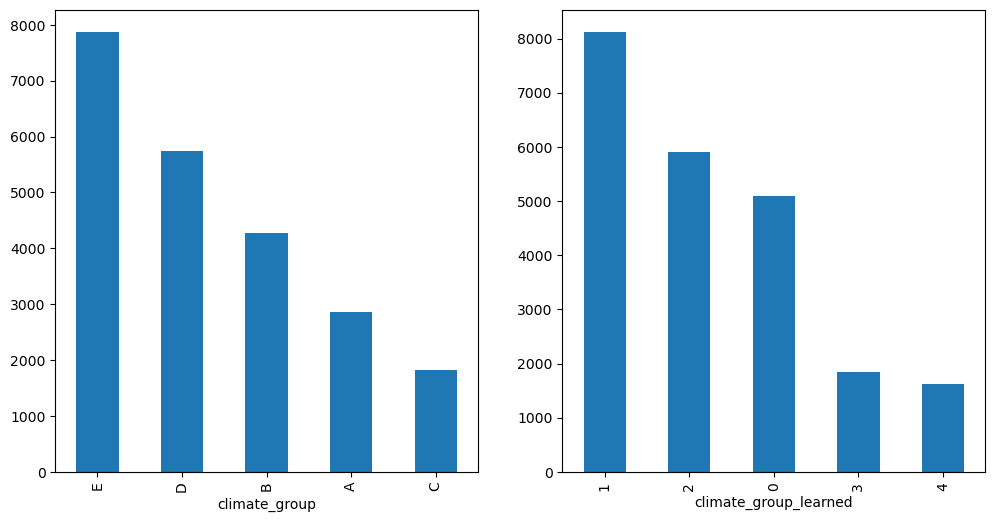

In [53]:
fig1 = matplotlib.pyplot.figure(figsize=(12,6))
ax1 = fig1.add_subplot(1,2,1)
zones_clustered['climate_group'].value_counts().plot.bar()
ax1 = fig1.add_subplot(1,2,2)
zones_clustered['climate_group_learned'].value_counts().plot.bar()

# Exercises

Once you have worked through the tutorial above, you can test your knowledge by adapting the code in the tutorial to experiment with different options for training the model and comparing results.

### Historic and future comparison
So far we have put all the data from historic and future scenarios together into one big dataset. The mapping from climate variables to climate zones should be the same in the future, even as the climate zones of particular places changes. We can test that by using historic data as our training set and then use future scenarios as our test data.  

In [ ]:
# insert  code here

### Divide train/test by geographic region
Doing our train/test split randomly, we are likely to have lots of correlations between examples in the train/val/test sets. One way we could reduce this is by spliting by geographic region. As the zones are highly corrlated with latitude, we couldn't use latitude for splitting. Instead we could divide by longitude. We would need to ensure all zones are represented in train, val and test sets.

In [ ]:
# insert  code here

### Addressing class imbalance
We have seen that the number of memebers of different classes 

In [ ]:
# insert  code here

In [ ]:
# train on historic data and predict on future data

In [ ]:
# try to divide train/test by geographic region. Use longitude 

In [ ]:
# try to balance classes in train set and compare results

### Work with More classes or higher resolution 


In [ ]:
# Try to load the 0.5 degree data and work with that

In [ ]:
# try to create a classifier for all 30 climate subgroups as the target

### Next steps or potential follow on material

Additional excercises in this tutorial material includes:
- Training a neural network using pytorch
- Training a CNN autoencoder on CMIP6 data
- Training a RNN on Jena weather dataset for time series prediction. 


### Data statement
This data used in this notebook is derived from the Koppen-Geiger Climate Cliassfication dataset created by GloH2O.

###     References
- [Climate Zones Dataset](https://www.gloh2o.org/koppen/#:~:text=The%20K%C3%B6ppen%2DGeiger%20climate%20classification%20maps%20are%20high%2Dresolution,Climate%20Sensitivity%20(ECS)%2C%20and%20historical%20warming%20trend)
